# Data Analysis Of Google Play Store

**Google Play Store**, formerly Android Market, is a digital distribution service developed by Google. It serves as the official app store for devices running on "Google certified" Android operating system, allowing users to browse and download applications published through Google. Google Play was launched on March 6, 2012. I found this dataset on Kaggle.

###  The libraries which we are going to use are :


*  Numpy
* Pandas
* Matplotlib
* Seaborn

### How to run the code

This is an executable [*Jupyter notebook*](https://jupyter.org) hosted on [Jovian.ml](https://www.jovian.ml), a platform for sharing data science projects. You can run and experiment with the code in a couple of ways: *using free online resources* (recommended) or *on your own computer*.

#### Option 1: Running using free online resources (1-click, recommended)

The easiest way to start executing this notebook is to click the "Run" button at the top of this page, and select "Run on Binder". This will run the notebook on [mybinder.org](https://mybinder.org), a free online service for running Jupyter notebooks. You can also select "Run on Colab" or "Run on Kaggle".


#### Option 2: Running on your computer locally

1. Install Conda by [following these instructions](https://conda.io/projects/conda/en/latest/user-guide/install/index.html). Add Conda binaries to your system `PATH`, so you can use the `conda` command on your terminal.

2. Create a Conda environment and install the required libraries by running these commands on the terminal:

```
conda create -n zerotopandas -y python=3.8 
conda activate zerotopandas
pip install jovian jupyter numpy pandas matplotlib seaborn opendatasets --upgrade
```

3. Press the "Clone" button above to copy the command for downloading the notebook, and run it on the terminal. This will create a new directory and download the notebook. The command will look something like this:

```
jovian clone notebook-owner/notebook-id
```



4. Enter the newly created directory using `cd directory-name` and start the Jupyter notebook.

```
jupyter notebook
```

You can now access Jupyter's web interface by clicking the link that shows up on the terminal or by visiting http://localhost:8888 on your browser. Click on the notebook file (it has a `.ipynb` extension) to open it.


## Downloading the Dataset

First of all, Download the data set from Kaggle.

In [2]:
!pip install jovian opendatasets --upgrade --quiet

Let's begin by downloading the data, and listing the files within the dataset.

In [3]:
dataset_url = 'https://www.kaggle.com/lava18/google-play-store-apps' 

In [ ]:
import opendatasets as od
od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: charvyjain


The dataset has been downloaded and extracted.

In [5]:
data_dir = './google-play-store-apps'

In [6]:
import os
os.listdir(data_dir)

['googleplaystore.csv', 'license.txt', 'googleplaystore_user_reviews.csv']

Let us save and upload our work to Jovian before continuing.

In [7]:
project_name = "data-analysis-of-google-play-store" 

In [8]:
!pip install jovian --upgrade -q

In [75]:
import jovian

In [76]:
jovian.commit(project=project_name)

[jovian] Detected Colab notebook...
[jovian] Uploading colab notebook to Jovian...
[jovian] Capturing environment..
[jovian] Committed successfully! https://jovian.ml/charvyjain3/data-analysis-of-google-play-store


'https://jovian.ml/charvyjain3/data-analysis-of-google-play-store'

## Data Preparation and Cleaning

**Let's begin with exploring the data set and then handling missing, incorrect and inavalid data.**



Importing the Libraries.

In [11]:
import numpy as np
import pandas as pd

Reading the data set.

In [12]:
gps_df = pd.read_csv('google-play-store-apps/googleplaystore.csv')

In [13]:
gps_df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


### Lets see at some insights of the data

In [23]:
gps_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [24]:
gps_df.shape

(10841, 13)

Here, the dataset contains total of 13 columns.
The Columns are :

In [25]:
gps_df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

**Top five rows :**

In [26]:
gps_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


**Last 10 rows :**

In [27]:
gps_df.tail(11)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10830,News Minecraft.fr,NEWS_AND_MAGAZINES,3.8,881,2.3M,"100,000+",Free,0,Everyone,News & Magazines,"January 20, 2014",1.5,1.6 and up
10831,payermonstationnement.fr,MAPS_AND_NAVIGATION,NaN,38,9.8M,"5,000+",Free,0,Everyone,Maps & Navigation,"June 13, 2018",2.0.148.0,4.0 and up
10832,FR Tides,WEATHER,3.8,1195,582k,"100,000+",Free,0,Everyone,Weather,"February 16, 2014",6.0,2.1 and up
10833,Chemin (fr),BOOKS_AND_REFERENCE,4.8,44,619k,"1,000+",Free,0,Everyone,Books & Reference,"March 23, 2014",0.8,2.2 and up
10834,FR Calculator,FAMILY,4.0,7,2.6M,500+,Free,0,Everyone,Education,"June 18, 2017",1.0.0,4.1 and up
10835,FR Forms,BUSINESS,NaN,0,9.6M,10+,Free,0,Everyone,Business,"September 29, 2016",1.1.5,4.0 and up
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


### Handling NULL Values
**This is a very crucial step in every analysis and model, which on doing, improves the accuracy of Insights and Predictions.**

In [28]:
print(gps_df.isnull().sum())
gps_df.dropna(inplace=True) # Dropping Rows with Null values

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64


Removing Duplicate entries.

In [29]:
gps_df.drop_duplicates(inplace=True)  

#### Type Column :

In [30]:
gps_df['Type'].unique()

array(['Free', 'Paid'], dtype=object)

In [31]:
gps_df['Type'].replace(to_replace=['0'], value=['Free'],inplace=True)
gps_df['Type'].fillna('Free', inplace=True)

#### Rating Column :

In [32]:
gps_df['Rating'].unique() 

array([4.1, 3.9, 4.7, 4.5, 4.3, 4.4, 3.8, 4.2, 4.6, 4. , 4.8, 4.9, 3.6,
       3.7, 3.2, 3.3, 3.4, 3.5, 3.1, 5. , 2.6, 3. , 1.9, 2.5, 2.8, 2.7,
       1. , 2.9, 2.3, 2.2, 1.7, 2. , 1.8, 2.4, 1.6, 2.1, 1.4, 1.5, 1.2])

In [33]:
gps_df['Rating'] = pd.to_numeric(gps_df['Rating'], errors='coerce')
gps_df['Rating'].dtype

dtype('float64')

#### Reviews Column :

In [34]:
gps_df['Reviews'].unique()

array(['159', '967', '87510', ..., '603', '1195', '398307'], dtype=object)

In [35]:
gps_df['Reviews'] = gps_df['Reviews'].apply(lambda x: int(x))
gps_df['Reviews'].dtype

dtype('int64')

#### Size Column :

In [36]:
gps_df['Size'].unique()

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '5.5M', '17M', '39M', '31M',
       '4.2M', '23M', '6.0M', '6.1M', '4.6M', '9.2M', '5.2M', '11M',
       '24M', 'Varies with device', '9.4M', '15M', '10M', '1.2M', '26M',
       '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k', '3.6M', '5.7M',
       '8.6M', '2.4M', '27M', '2.7M', '2.5M', '7.0M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '22M', '6.4M', '3.2M', '8.2M', '4.9M', '9.5M', '5.0M',
       '5.9M', '13M', '73M', '6.8M', '3.5M', '4.0M', '2.3M', '2.1M',
       '42M', '9.1M', '55M', '23k', '7.3M', '6.5M', '1.5M', '7.5M', '51M',
       '41M', '48M', '8.5M', '46M', '8.3M', '4.3M', '4.7M', '3.3M', '40M',
       '7.8M', '8.8M', '6.6M', '5.1M', '61M', '66M', '79k', '8.4M',
       '3.7M', '118k', '44M', '695k', '1.6M', '6.2M', '53M', '1.4M',
      

Should remove 'k', 'M', '+' for better analysis

In [37]:
gps_df['Size'] = gps_df.Size.replace("Varies with device",np.nan)
gps_df['Size'] = gps_df.Size.str.replace("M","000")  # All size values became the kilobyte type.
gps_df['Size'] = gps_df.Size.str.replace("k","")
gps_df['Size'] = gps_df.Size.replace("1,000+",1000)
gps_df['Size'] = gps_df['Size'].astype(float)
gps_df['Size'].dtype

dtype('float64')

#### Installs Column :

In [38]:
gps_df['Installs'].unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '100+', '500+', '10+',
       '5+', '50+', '1+'], dtype=object)

Should remove '+' for better analysis

In [39]:
gps_df.Installs = gps_df.Installs.replace("Free", np.nan)
gps_df.dropna(how ='any', inplace = True)
gps_df.Installs = gps_df.Installs.astype(str)
gps_df.Installs = gps_df.Installs.apply(lambda x: x.replace(',',''))
gps_df.Installs = gps_df.Installs.apply(lambda x: x.replace('+',''))
gps_df.Installs = gps_df.Installs.apply(lambda x: int(x))

#### Price Column :

In [40]:
gps_df['Price'].unique()

array(['0', '$4.99', '$6.99', '$7.99', '$3.99', '$5.99', '$2.99', '$1.99',
       '$9.99', '$0.99', '$9.00', '$5.49', '$10.00', '$24.99', '$11.99',
       '$79.99', '$16.99', '$14.99', '$29.99', '$12.99', '$3.49',
       '$10.99', '$7.49', '$1.50', '$19.99', '$15.99', '$33.99', '$39.99',
       '$2.49', '$4.49', '$1.70', '$1.49', '$3.88', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$1.59',
       '$6.49', '$1.29', '$299.99', '$379.99', '$37.99', '$18.99',
       '$389.99', '$8.49', '$1.75', '$14.00', '$2.00', '$3.08', '$2.59',
       '$19.40', '$15.46', '$8.99', '$3.04', '$13.99', '$4.29', '$3.28',
       '$4.60', '$1.00', '$2.90', '$1.97', '$2.56', '$1.20'], dtype=object)

Should remove "$" sign from "Price" column and and convert each value of the column to numeric value

In [41]:
gps_df['Price'] = gps_df.Price.replace("Everyone",np.nan)
gps_df['Price'] = gps_df.Price.str.replace("$","").astype(float)
gps_df['Price'].dtype

dtype('float64')

#### Last Updated Column :

In [42]:
gps_df.rename(columns = {'Last Updated':'Last_updated'}, inplace = True)

In [43]:
gps_df['Last_updated'].unique()

array(['January 7, 2018', 'January 15, 2018', 'August 1, 2018', ...,
       'January 20, 2014', 'February 16, 2014', 'March 23, 2014'],
      dtype=object)

In [44]:
gps_df['Last_updated'] = pd.to_datetime(gps_df['Last_updated'])
gps_df['Last_updated']

0       2018-01-07
1       2018-01-15
2       2018-08-01
3       2018-06-08
4       2018-06-20
           ...    
10833   2014-03-23
10834   2017-06-18
10836   2017-07-25
10837   2018-07-06
10840   2018-07-25
Name: Last_updated, Length: 7418, dtype: datetime64[ns]

#### Android Ver Column :

In [45]:
gps_df.rename(columns = {'Android Ver':'Android_ver'}, inplace = True)

Let's now view some basic statistics about the the numeric columns.

In [46]:
gps_df.describe()

,Rating,Reviews,Size,Installs,Price
count,7418.000000,7.418000e+03,7418.000000,7.418000e+03,7418.000000
mean,4.171394,2.789961e+05,20863.873578,7.830035e+06,1.117168
std,0.549812,1.744309e+06,24909.471071,4.632233e+07,17.715707
min,1.000000,1.000000e+00,1.000000,1.000000e+00,0.000000
25%,4.000000,9.900000e+01,5.900000,1.000000e+04,0.000000
50%,4.300000,2.067500e+03,14000.000000,1.000000e+05,0.000000
75%,4.500000,3.690075e+04,33000.000000,1.000000e+06,0.000000
max,5.000000,4.489389e+07,100000.000000,1.000000e+09,400.000000


In [47]:
import jovian

In [48]:
jovian.commit(project=project_name)

[jovian] Detected Colab notebook...
[jovian] Uploading colab notebook to Jovian...
[jovian] Capturing environment..
[jovian] Committed successfully! https://jovian.ml/charvyjain3/data-analysis-of-google-play-store


'https://jovian.ml/charvyjain3/data-analysis-of-google-play-store'

## Exploratory Analysis and Visualization

**So as Data cleaning is completed and now the dataset is ready to be worked upon, lets start with some visual analysis as visual analysis is the best way to extract information from the raw data.**

Let's begin by importing`matplotlib.pyplot` and `seaborn`.

In [49]:
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (9, 5)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

 ### CATEGORIES

These are the names of various categories :

In [ ]:
categories = gps_df.Category.unique()
categories

array(['ART_AND_DESIGN', 'AUTO_AND_VEHICLES', 'BEAUTY',
       'BOOKS_AND_REFERENCE', 'BUSINESS', 'COMICS', 'COMMUNICATION',
       'DATING', 'EDUCATION', 'ENTERTAINMENT', 'EVENTS', 'FINANCE',
       'FOOD_AND_DRINK', 'HEALTH_AND_FITNESS', 'HOUSE_AND_HOME',
       'LIBRARIES_AND_DEMO', 'LIFESTYLE', 'GAME', 'FAMILY', 'MEDICAL',
       'SOCIAL', 'SHOPPING', 'PHOTOGRAPHY', 'SPORTS', 'TRAVEL_AND_LOCAL',
       'TOOLS', 'PERSONALIZATION', 'PRODUCTIVITY', 'PARENTING', 'WEATHER',
       'VIDEO_PLAYERS', 'NEWS_AND_MAGAZINES', 'MAPS_AND_NAVIGATION'],
      dtype=object)

Let's look at the number of apps in each category by barplot.

<AxesSubplot:xlabel='Category'>

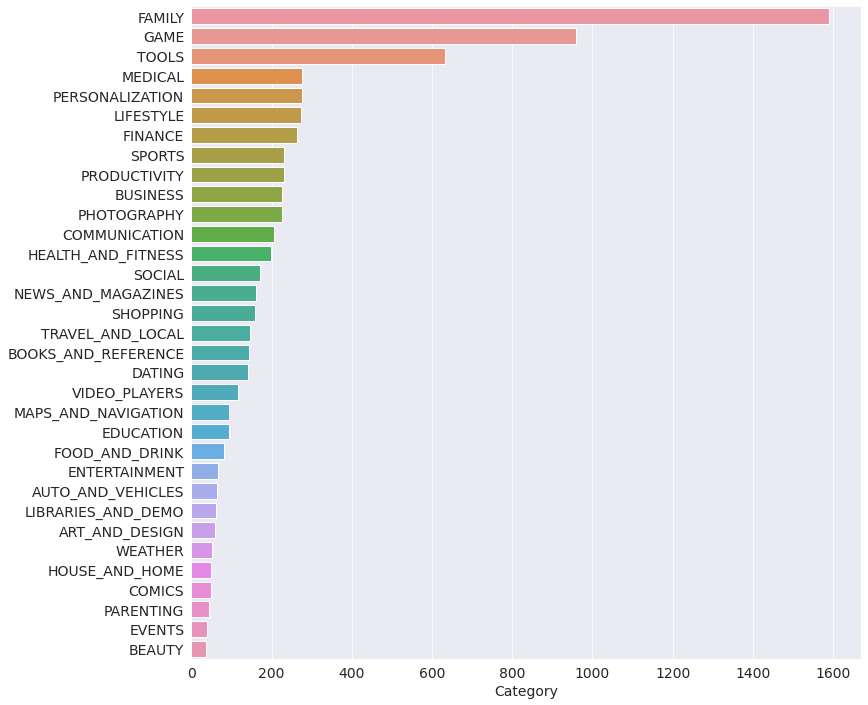

In [ ]:
plt.figure(figsize=(12,12))
categories = gps_df.Category.value_counts()
sns.barplot(x=categories, y=categories.index, data=gps_df) 

**Insight** : Maximum Number of Apps belong to the **Family and Game** Category.
There are around 1700 app with Family category, followed by Game category with 1200 apps.

### RATING

In [ ]:
gps_df.Rating.unique() 

array([4.1, 3.9, 4.7, 4.5, 4.3, 4.4, 3.8, 4.2, 4.6, 4. , 4.8, 4.9, 3.6,
       3.7, 3.2, 3.3, 3.4, 3.5, 3.1, 5. , 2.6, 3. , 1.9, 2.5, 2.8, 2.7,
       1. , 2.9, 2.3, 2.2, 1.7, 2. , 1.8, 2.4, 1.6, 2.1, 1.4, 1.5, 1.2])

Let's look at the Distribution plot of Ratings.

<AxesSubplot:xlabel='Rating'>

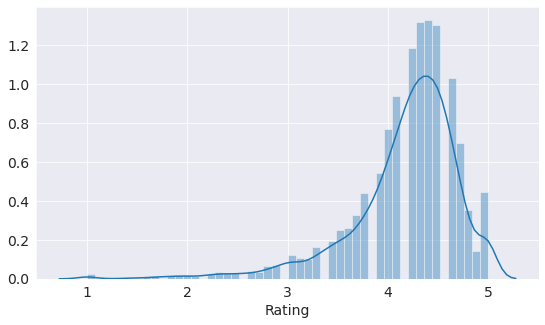

In [ ]:
sns.distplot(gps_df.Rating)

**Insight** : Most of the apps, clearly hold a rating **above 4.0 **! And a lot seem to have 5.0 rating.

### CATEGORY AND TYPE

Let's group category and type to figure out the paid and free apps across different categories.

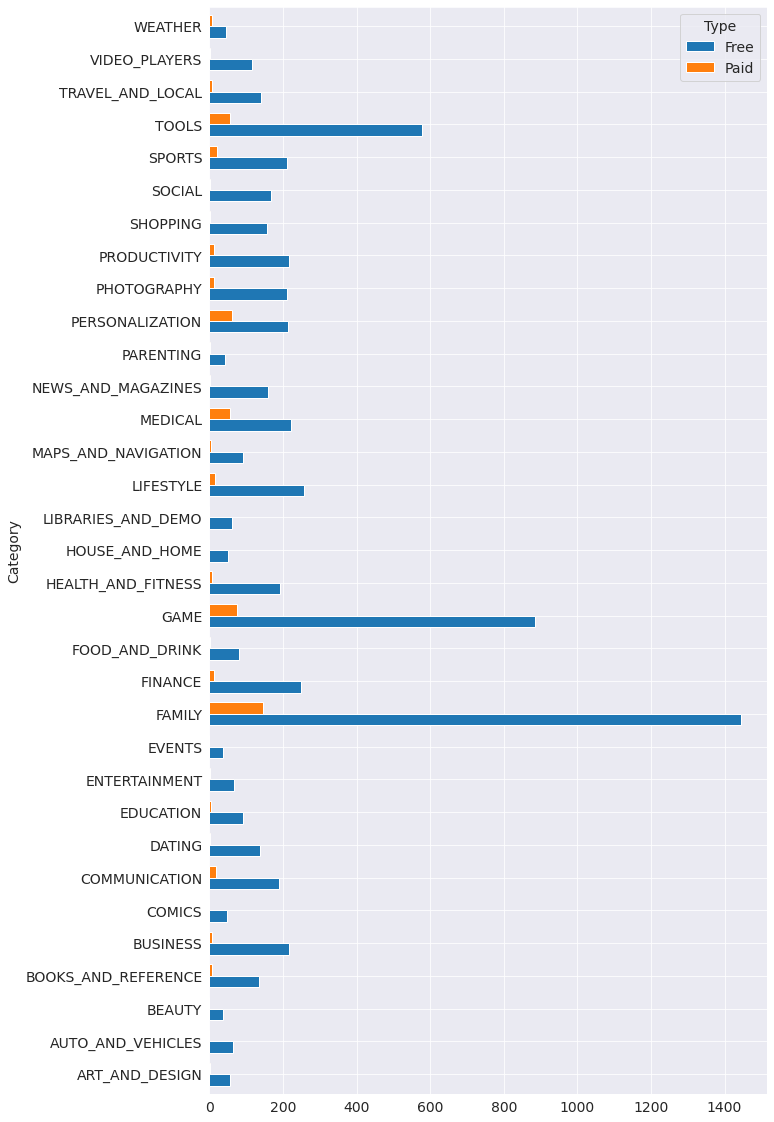

In [ ]:
Type_category = gps_df.groupby('Category')['Type'].value_counts().unstack().plot.barh(figsize=(10,20), width=0.7)
plt.show()

**Insight** : So again, Family category has the most free and paid apps followed by Tools. Also observe that social apps like entertainment, event, education, comic, and more are always free. 

#### CONTENT RATING 

Let's see content rating by bar plot.

<AxesSubplot:>

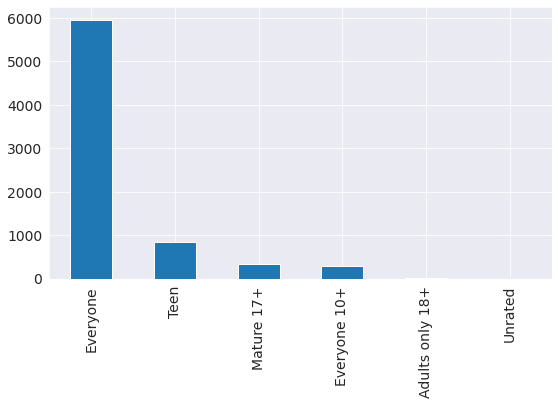

In [ ]:
gps_df['Content Rating'].value_counts().plot(kind='bar')

#### PAID APPS

Text(0.5, 1.0, '% Distribution of Paid Apps Genres')

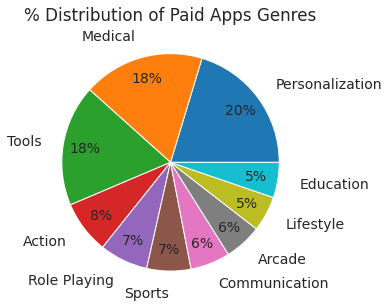

In [50]:
paided = gps_df[gps_df['Type'] == 'Paid']
gps_df = paided['Genres'].value_counts()
gps_df = gps_df.reset_index()
gps_df = gps_df[:10]
plt.figure(figsize=(10,5))
plt.pie(x = list(gps_df['Genres']), labels=list(gps_df['index']), autopct='%1.0f%%', pctdistance=0.8, labeldistance=1.2)
plt.title('% Distribution of Paid Apps Genres')

**Insight**: From above pie chart, most of the paid apps are from **Personalization** Genre and least are from education and lifestyle.

Let us save and upload our work to Jovian before continuing

In [71]:
import jovian

In [72]:
jovian.commit(project = project_name)

[jovian] Detected Colab notebook...
[jovian] Uploading colab notebook to Jovian...
[jovian] Capturing environment..
[jovian] Committed successfully! https://jovian.ml/charvyjain3/data-analysis-of-google-play-store


'https://jovian.ml/charvyjain3/data-analysis-of-google-play-store'

## Asking and Answering Questions

We've already gained several insights about apps exploring some columns of the dataset. Let's ask some specific questions, and try to answer them using data frame operations and interesting visualizations.



### Q1:  Is there a relation between the Android Update Dates of all the Apps?

Text(0.5, 1.0, 'Time series plot of Last Updates')

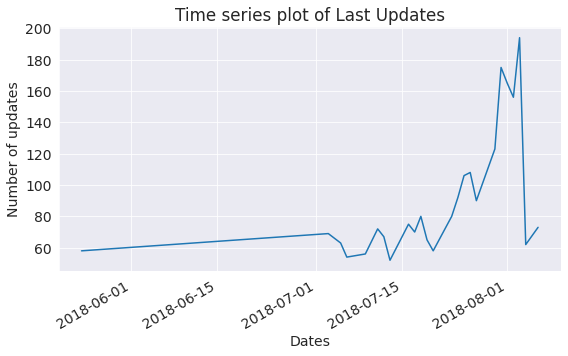

In [ ]:
freq = pd.Series([], dtype=pd.StringDtype()) 
freq = gps_df['Last_updated'].value_counts()
newfreq = freq[freq>50]
newfreq.plot()
plt.xlabel("Dates")
plt.ylabel("Number of updates")
plt.title("Time series plot of Last Updates")

**Insight:** I have selected the dates on which most number of Apps were last updated.
The above plot shows that between **July 15,2018 and August 1,2018** majority of the Apps were updated as it is clear by the upward trend in the graph above.

### Q2: What are the top 10 Expensive apps?

In [ ]:
def expensive(count=5):
    exp = gps_df.sort_values(by=["Price"],ascending = False).head(count)
    return exp
expensive(10)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last_updated,Current Ver,Android_ver
4367,I'm Rich - Trump Edition,LIFESTYLE,3.6,275,7.3,10000,Paid,400.00,Everyone,Lifestyle,2018-05-03,1.0.1,4.1 and up
4197,most expensive app (H),FAMILY,4.3,6,1.5,100,Paid,399.99,Everyone,Entertainment,2018-07-16,1.0,7.0 and up
5369,I am Rich,FINANCE,4.3,180,3.8,5000,Paid,399.99,Everyone,Finance,2018-03-22,1.0,4.2 and up
5358,I am Rich!,FINANCE,3.8,93,22000.0,1000,Paid,399.99,Everyone,Finance,2017-12-11,1.0,4.1 and up
5354,I am Rich Plus,FAMILY,4.0,856,8.7,10000,Paid,399.99,Everyone,Entertainment,2018-05-19,3.0,4.4 and up
5359,I am rich(premium),FINANCE,3.5,472,965.0,5000,Paid,399.99,Everyone,Finance,2017-05-01,3.4,4.4 and up
5351,I am rich,LIFESTYLE,3.8,3547,1.8,100000,Paid,399.99,Everyone,Lifestyle,2018-01-12,2.0,4.0.3 and up
5362,I Am Rich Pro,FAMILY,4.4,201,2.7,5000,Paid,399.99,Everyone,Entertainment,2017-05-30,1.54,1.6 and up
5364,I am rich (Most expensive app),FINANCE,4.1,129,2.7,1000,Paid,399.99,Teen,Finance,2017-12-06,2,4.0.3 and up
4362,💎 I'm rich,LIFESTYLE,3.8,718,26000.0,10000,Paid,399.99,Everyone,Lifestyle,2018-03-11,1.0.0,4.4 and up


**Insight:** As we can see, The most expensive app  **I'm Rich - Trump Edition** which costs **$400** We can also represent this graphically as below.

/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:214: RuntimeWarning: Glyph 128142 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:183: RuntimeWarning: Glyph 128142 missing from current font.
  font.set_text(s, 0, flags=flags)


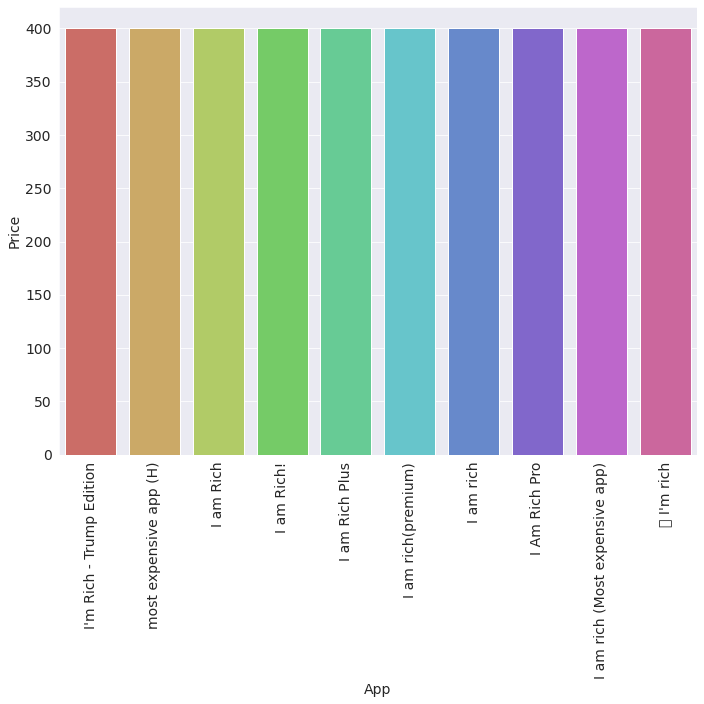

In [ ]:
exp = gps_df.sort_values(by=["Price"],ascending = False).head(11)
plt.figure(figsize=(10,10))
fig = sns.barplot(x=exp['App'][:10], y=exp['Price'][:10], palette="hls")
fig.set_xticklabels(fig.get_xticklabels(),rotation=90)
plt.tight_layout()
plt.show(fig)

### Q3: What are best apps ?

The criteria I have selected are:
*  High rating
*  Large number of reviews
* Large number of installs

I think features like Content Rating, Android Version, Last Update time, Size of the App, Price and  Current version of the App are irrelevant in this selection for obvious reasons.

In [ ]:
gps_df['Rating'] = gps_df['Rating'].apply(lambda x: float(x))
gps_df['Reviews'] = gps_df['Reviews'].apply(lambda x: int(x))

df_ratings = gps_df[['App','Rating','Category','Content Rating']].groupby(['Rating'], sort = True)
df_ratings = df_ratings.filter(lambda x: x['Rating'].mean() >= 4.5)
df_ratings = df_ratings.sort_values(by=['Rating'])

df_reviews = gps_df[['App','Reviews']].groupby(['Reviews'], sort = True)
df_reviews = df_reviews.filter(lambda x: x['Reviews'].mean() >= 255435)
df_reviews = df_reviews.sort_values(by=['Reviews'])

newdf_installs = gps_df[['App','Installs']].groupby(['Installs'], sort = True)
newdf_installs = newdf_installs.filter(lambda x: x['Installs'].mean() >= 10000000)
newdf_installs = newdf_installs.sort_values(by=['Installs'])

P1 = pd.merge(df_reviews, df_ratings, how='inner', on=['App'])
P2 = pd.merge(s1, newdf_installs, how='inner', on=['App'])
P2

,App,Reviews,Rating,Category,Content Rating,Installs
0,TRANSFORMERS: Earth Wars,256219,4.5,FAMILY,Everyone,10000000
1,Pocket,256680,4.5,NEWS_AND_MAGAZINES,Everyone,10000000
2,LightX Photo Editor & Photo Effects,259450,4.7,PHOTOGRAPHY,Everyone,10000000
3,Geometry Dash SubZero,260527,4.6,GAME,Everyone,10000000
4,Rush,260651,4.6,GAME,Everyone,10000000
...,...,...,...,...,...,...
2528,Clash of Clans,44893888,4.6,GAME,Everyone 10+,100000000
2529,Clash of Clans,44893888,4.6,GAME,Everyone 10+,100000000
2530,Clash of Clans,44893888,4.6,FAMILY,Everyone 10+,100000000
2531,Clash of Clans,44893888,4.6,FAMILY,Everyone 10+,100000000


**Insight:** As we can see there are arounf 2000 apps make it to this list from all categories.

### Q4: Are there any apps which have not been updated since years ?

For this we are going to add two more columns named ***Year*** and ***Month***

In [ ]:
d = pd.DatetimeIndex(gps_df['Last_updated'])
gps_df['year'] = d.year
gps_df['month'] = d.month

In [ ]:
gps_df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last_updated,Current Ver,Android_ver,year,month
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,2018,1
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,2018,1
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,2018,8
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,2018,6
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,2018,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10833,Chemin (fr),BOOKS_AND_REFERENCE,4.8,44,619.0,1000,Free,0.0,Everyone,Books & Reference,2014-03-23,0.8,2.2 and up,2014,3
10834,FR Calculator,FAMILY,4.0,7,2.6,500,Free,0.0,Everyone,Education,2017-06-18,1.0.0,4.1 and up,2017,6
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53000.0,5000,Free,0.0,Everyone,Education,2017-07-25,1.48,4.1 and up,2017,7
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6,100,Free,0.0,Everyone,Education,2018-07-06,1.0,4.1 and up,2018,7


In [ ]:
print('Number of apps that has not been updated since 2017 are {}'.format(len(gps_df[gps_df['year'] < 2017])))
print('Number of apps that has not been updated since 2016 are {}'.format(len(gps_df[gps_df['year'] < 2016])))
print('Number of apps that has not been updated since 2015 {}'.format(len(gps_df[gps_df['year'] < 2015])))
print('Number of apps that has not been updated since 2014 {}'.format(len(gps_df[gps_df['year'] < 2014])))                                                               

Number of apps that has not been updated since 2017 are 1258
Number of apps that has not been updated since 2016 are 670
Number of apps that has not been updated since 2015 300
Number of apps that has not been updated since 2014 122


**Insight:** There are around 7400 apps that are not been updated since years, may be these apps might not be in service     

### Q5: How app Ratings differs in various Categories ? 

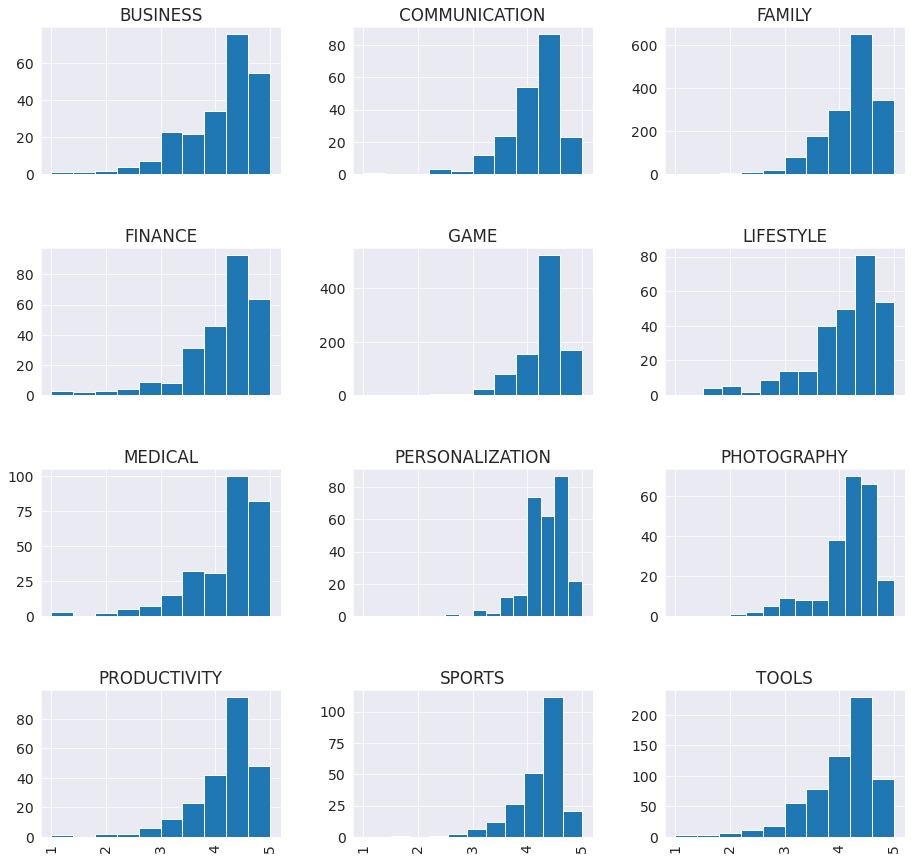

In [ ]:
# Exploring app ratings across top categories
groups = gps_df.groupby('Category').filter(lambda x: len(x) > 200).reset_index()
array = groups['Rating'].hist(by=groups['Category'], sharex=True, figsize=(15,15))

In [69]:
import jovian

In [70]:
jovian.commit(project = project_name)

[jovian] Detected Colab notebook...
[jovian] Uploading colab notebook to Jovian...
[jovian] Capturing environment..
[jovian] Committed successfully! https://jovian.ml/charvyjain3/data-analysis-of-google-play-store


'https://jovian.ml/charvyjain3/data-analysis-of-google-play-store'

### FURTHER ANALYSIS

In [ ]:
df = gps_df[gps_df.Rating == 5]
df.head(11)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last_updated,Current Ver,Android_ver
329,Hojiboy Tojiboyev Life Hacks,COMICS,5.0,15,37000.0,1000,Free,0.0,Everyone,Comics,2018-06-26,2.0,4.0.3 and up
612,American Girls Mobile Numbers,DATING,5.0,5,4.4,1000,Free,0.0,Mature 17+,Dating,2018-07-17,3.0,4.0.3 and up
615,Awake Dating,DATING,5.0,2,70000.0,100,Free,0.0,Mature 17+,Dating,2018-07-24,2.2.9,4.4 and up
633,Spine- The dating app,DATING,5.0,5,9.3,500,Free,0.0,Teen,Dating,2018-07-14,4.0,4.0.3 and up
636,Girls Live Talk - Free Text and Video Chat,DATING,5.0,6,5.0,100,Free,0.0,Mature 17+,Dating,2018-08-01,8.2,4.0.3 and up
640,Online Girls Chat Group,DATING,5.0,5,5.0,100,Free,0.0,Mature 17+,Dating,2018-08-02,8.2,4.0.3 and up
654,Speeding Joyride & Car Meet App,DATING,5.0,3,25000.0,100,Free,0.0,Mature 17+,Dating,2018-07-20,1.2.9,4.1 and up
1028,SUMMER SONIC app,EVENTS,5.0,4,61000.0,500,Free,0.0,Everyone,Events,2018-07-24,1.0,4.4 and up
1030,Prosperity,EVENTS,5.0,16,2.3,100,Free,0.0,Everyone,Events,2018-07-09,1.14,2.0 and up
1038,Mindvalley U Tallinn 2018,EVENTS,5.0,1,21000.0,100,Free,0.0,Everyone,Events,2018-07-03,1.0.5,4.4 and up


There are Apps that have full Ratings but less Installs. So we can't really consider those apps as the best ones.

So, We should Consider the Apps with 5.0 Ratings and Maximum Installs.

In [ ]:
df_maxinstalls = df[gps_df.Installs > 1000]
df_maxinstalls[['App', 'Category', 'Installs']]

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  """Entry point for launching an IPython kernel.


,App,Category,Installs
7514,CL Keyboard - Myanmar Keyboard (No Ads),TOOLS,5000
8058,Oración CX,LIFESTYLE,5000
8260,"Superheroes, Marvel, DC, Comics, TV, Movies News",COMICS,5000
9511,Ek Bander Ne Kholi Dukan,FAMILY,10000


We can also check No. of Reviews of 5.0 Rating Apps

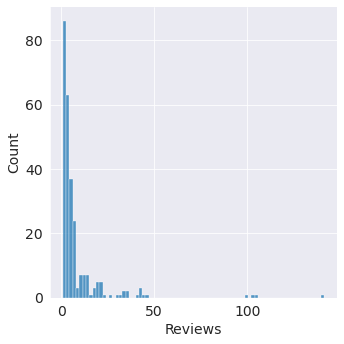

In [ ]:
sns.displot(df.Reviews)

 The above distribution is clearly skewed. Apps with very few Reviews easily managed to get 5.0 Ratings which can be misleading.
So let's filter out the ones with more than 30 reviews. These filtered ones are the apps that really stand for 5.0 rating.¶

In [ ]:
df = df[gps_df.Reviews > 30]
print("No. of Apps having 5.0 Rating with sufficient Reviews: ",df.App.count())

No. of Apps having 5.0 Rating with sufficient Reviews:  15


/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  """Entry point for launching an IPython kernel.


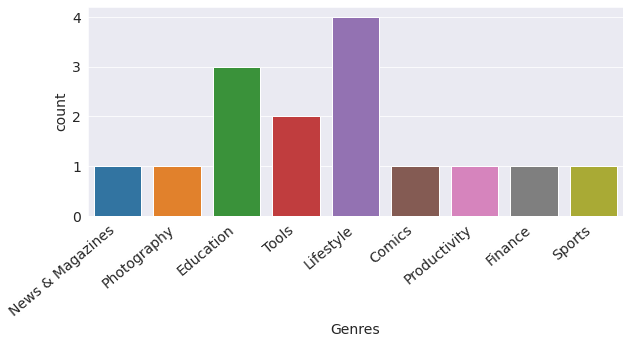

In [ ]:
fig = sns.countplot(x=df.Genres)
fig.set_xticklabels(fig.get_xticklabels(), rotation=40, ha="right")
plt.tight_layout()
plt.show()

**Insight** : Apps related to Education, LifeStyle and Tools seem to fetch full Ratings with sufficient number of reviews.

### Are Paid apps worth buying? (Analysis based on Average User Rating)

In [ ]:
paid_apps = gps_df.loc[gps_df['Type'] == "Paid"]
free_apps = gps_df.loc[gps_df['Type'] == "Free"]

In [ ]:
paid_apps = paid_apps.drop_duplicates(keep='first')
paid_apps.head(5)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last_updated,Current Ver,Android_ver
234,TurboScan: scan documents and receipts in PDF,BUSINESS,4.7,11442,6.8,100000,Paid,4.99,Everyone,Business,2018-03-25,1.5.2,4.0 and up
235,Tiny Scanner Pro: PDF Doc Scan,BUSINESS,4.8,10295,39000.0,100000,Paid,4.99,Everyone,Business,2017-04-11,3.4.6,3.0 and up
477,Calculator,DATING,2.6,57,6.2,1000,Paid,6.99,Everyone,Dating,2017-10-25,1.1.6,4.0 and up
481,AMBW Dating App: Asian Men Black Women Interra...,DATING,3.5,2,17000.0,100,Paid,7.99,Mature 17+,Dating,2017-01-21,1.0.1,4.0 and up
851,Sago Mini Hat Maker,EDUCATION,4.9,11,63000.0,1000,Paid,3.99,Everyone,Education;Pretend Play,2017-07-24,1.0,4.0.3 and up


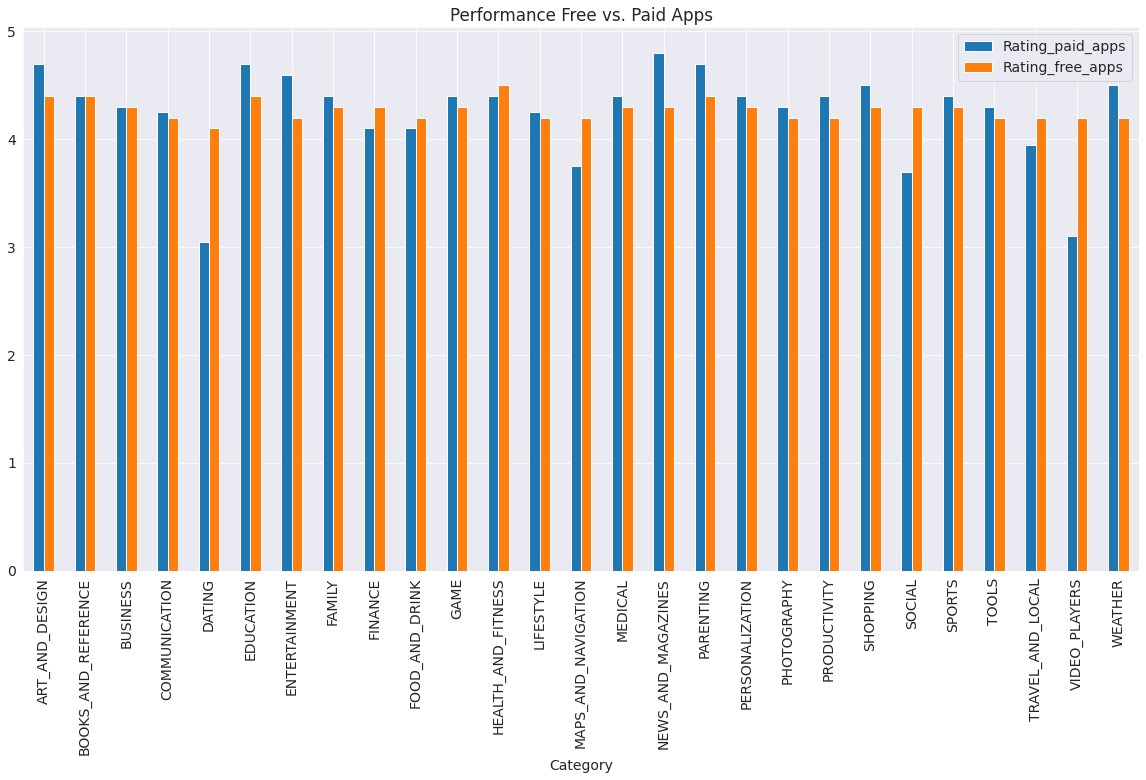

In [ ]:
df1 = paid_apps.groupby(["Category"])["Rating"].median().sort_values(ascending=False).to_frame()
df2 = free_apps.groupby(["Category"])["Rating"].median().sort_values(ascending=False).to_frame()
rating_comparison = df1.join(df2,on='Category',lsuffix='_paid_apps',rsuffix='_free_apps').sort_values('Category')

fig3 = rating_comparison.plot(kind='bar',y=['Rating_paid_apps','Rating_free_apps'],title='Performance Free vs. Paid Apps',figsize=(20,10))

**Insight:** Looks like paid apps perform marginally better than the free apps

Let us save and upload our work to Jovian before continuing.

In [63]:
import jovian

In [64]:
jovian.commit(project=project_name)

[jovian] Detected Colab notebook...
[jovian] Uploading colab notebook to Jovian...
[jovian] Capturing environment..
[jovian] Committed successfully! https://jovian.ml/charvyjain3/data-analysis-of-google-play-store


'https://jovian.ml/charvyjain3/data-analysis-of-google-play-store'

## Inferences and Conclusion

**We just got a glance about the apps in Google Play Store and We've drawn many interesting inferences and some great results, here's a summary of the few of them:**


*   Most of the apps belongs to **Family** category followed by **Game** category.
*   The Rating is very high with at least 75% of the apps in the range **4.0 to 5.0.**
*    **Family** category has the most free and paid apps and social apps like entertainment are almost free.
* Some apps from category like Photography, Personalization, Medical are paid.
*  **31%** of paid apps belongs to Family category
*  Majority of the apps were updated between **July 15,2018 and August 1,2018.**
*   Most expensive App costs **400$** which is **I'm Rich - Trump Edition** from Lifestyle category.
* Acoording to my analysis, best 3 apps are :

 > **TRANSFORMERS: Earth Wars**

 > **Pocket**

 > **LightX Photo Editor & Photo Effects** 

* Most Apps require at least **4.1** android version.
* Number of apps that has not been updated since

1.  *2017* are **1258**
2.  *2016* are **670**
3.   *2015* are **300**
4. *2014* are **122**
* No. of Apps having 5.0 Rating with sufficient Reviews are **15**
* Apps related to **Education, LifeStyle and Tools** seem to have full Ratings with sufficient number of reviews.
*  Looks like paid apps perform marginally better than the free apps


In [ ]:
import jovian

In [16]:
jovian.commit(project=project_name)

[jovian] Detected Colab notebook...
[jovian] Uploading colab notebook to Jovian...
[jovian] Capturing environment..
[jovian] Committed successfully! https://jovian.ml/charvyjain3/data-analysis-of-google-play-store


'https://jovian.ml/charvyjain3/data-analysis-of-google-play-store'

## References and Future Work

We just did a bit of analysis and there is much more to explore. Given are some ideas :

* Which category are most likable apps ?
* How much do Free Apps and Paid Apps differ ?
* What are some of the popular paid apps according to Ratings, Reviews and Installs ?
* Find more datasets for Play store in the web and try to merge them.
* Explore further the data for every Genre.
* What is the average size of the applications ?

#### References :
* Numpy Documentation: https://numpy.org/devdocs/user/quickstart.html
* Pandas documentation: https://pandas.pydata.org/
* Matplotlib documentation: https://matplotlib.org/
* Seaborn documentaion: https://seaborn.pydata.org/
and of course,
* ZerotoPandas Tutorial by JovianML- https://jovian.ml/learn/data-analysis-with-python-zero-to-pandas


---



**Ah! Finally this project gave me an amazing opportunity to improve my skills and learn about Data analysis!
It was a fantastic journey of 6- weeks and I had a great experience. Thank you so much *@Aakash N S Sir* for organising this course.**

In [20]:
import jovian

In [22]:
jovian.commit(project = project_name)

[jovian] Detected Colab notebook...
[jovian] Uploading colab notebook to Jovian...
[jovian] Capturing environment..
[jovian] Committed successfully! https://jovian.ml/charvyjain3/data-analysis-of-google-play-store


'https://jovian.ml/charvyjain3/data-analysis-of-google-play-store'